# Public Transport Delay Prediction using Machine Learning

### Objective

Predict whether a public transport trip will be delayed.

**Target variable:** `delayed`

- `0` → On Time
- `1` → Delayed

This notebook follows the feature-engineering decisions from Notebook 2 and compares multiple model families suitable for this dataset.

### Important modelling principle

The classification model represents a **pre-trip prediction scenario**. Therefore, post-outcome variables such as:

- `actual_departure_delay_min`
- `actual_arrival_delay_min`

are not used as predictors.


## Why These Algorithms?

The dataset is a relatively small tabular classification problem with:

- 2,000 observations
- mixed numerical and categorical variables
- high-cardinality categorical variables such as routes and stations
- 172 features after one-hot encoding
- potentially nonlinear relationships and feature interactions
- an imbalanced target, with delayed trips forming the majority class

Different algorithms are therefore used to test different assumptions about the underlying data:

| Algorithm | Why it is included |
|---|---|
| Dummy Classifier | Establishes a no-learning baseline |
| Logistic Regression | Interpretable linear benchmark |
| Decision Tree | Captures nonlinear rules and interactions |
| Random Forest | Robust nonlinear tree ensemble |
| Extra Trees | More randomised tree ensemble |
| Gradient Boosting | Sequentially learns from previous errors |
| **XGBoost** | Strong, regularised boosting model for tabular data |
| KNN | Distance-based benchmark |
| Gaussian Naive Bayes | Simple probabilistic benchmark |
| SVM | High-dimensional nonlinear benchmark |

The purpose is not to assume one algorithm will be best, but to compare different modelling assumptions and select the approach that generalises best using validation performance.

In [21]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Train/Test Split

Notebook 2 is responsible for feature engineering and the supervised train/test split.

For reproducibility, this notebook uses the **exact split produced in Notebook 2**.

In [2]:
from pathlib import Path

data_dir = Path("../artifacts/splits")

required_split_files = [
    data_dir / "X_train_cls.csv",
    data_dir / "X_test_cls.csv",
    data_dir / "y_train_cls.csv",
    data_dir / "y_test_cls.csv"
]

missing_files = [str(p) for p in required_split_files if not p.exists()]

if missing_files:
    raise FileNotFoundError(
        "The classification train/test split has not been saved yet. "
        "Run the export cell described in the previous markdown cell at the "
        "end of Notebook 2, then rerun this notebook. Missing files:\n"
        + "\n".join(missing_files)
    )

X_train = pd.read_csv(data_dir / "X_train_cls.csv")
X_test = pd.read_csv(data_dir / "X_test_cls.csv")

y_train = pd.read_csv(
    data_dir / "y_train_cls.csv"
).squeeze("columns")

y_test = pd.read_csv(
    data_dir / "y_test_cls.csv"
).squeeze("columns")

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1600, 33)
Test set: (400, 33)


## Identify Feature Types

The train and test data contain the engineered features from Notebook 2.

The feature lists below must match the feature definitions used when the split was created.

In [3]:
categorical_features = [
    "transport_type",
    "route_id",
    "origin_station",
    "destination_station",
    "weather_condition",
    "event_type",
    "season",
    "day_of_week"
]

numerical_features = [
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "event_attendance_est",
    "log_event_attendance",
    "has_event",
    "year",
    "month",
    "day_of_month",
    "weekday_num",
    "is_weekend",
    "quarter",
    "departure_hour",
    "departure_minute",
    "arrival_hour",
    "arrival_minute",
    "departure_minutes",
    "arrival_minutes",
    "scheduled_trip_duration_min",
    "departure_hour_sin",
    "departure_hour_cos"
]

feature_columns = categorical_features + numerical_features

missing_columns = [
    col for col in feature_columns
    if col not in X_train.columns
]

if missing_columns:
    raise ValueError(
        "The saved split is missing expected modelling features: "
        + ", ".join(missing_columns)
    )
else:
    print("The feature lists match the feature definitions when the split was created. ")    

X_train = X_train[feature_columns].copy()
X_test = X_test[feature_columns].copy()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))
print("Total input features:", len(feature_columns))

The feature lists match the feature definitions when the split was created. 
Categorical features: 8
Numerical features: 25
Total input features: 33


## Final Leakage Check

Before training any model, explicitly verify that no identifier or post-outcome delay variable appears in the predictors.

In [4]:
leakage_or_identifier_columns = [
    "trip_id",
    "actual_departure_delay_min",
    "actual_arrival_delay_min"
]

for col in leakage_or_identifier_columns:
    if col in X_train.columns or col in X_test.columns:
        print(f"WARNING: {col} is present in the feature data")

assert not any(
    col in X_train.columns
    for col in leakage_or_identifier_columns
)

assert not any(
    col in X_test.columns
    for col in leakage_or_identifier_columns
)

print("Leakage and identifier check passed.")

Leakage and identifier check passed.


## Verifying the Target Distribution

The target distribution is checked again in the modelling notebook so that the model-selection strategy is directly connected to the observed class imbalance.

In [5]:
target_summary = pd.DataFrame({
    "Class": ["On Time (0)", "Delayed (1)"],
    "Count": [
        int((y_train == 0).sum()),
        int((y_train == 1).sum())
    ]
})

target_summary["Percentage"] = (
    target_summary["Count"] / len(y_train) * 100
).round(2)

target_summary

,Class,Count,Percentage
0,On Time (0),401,25.06
1,Delayed (1),1199,74.94


### Class-Imbalance Strategy

The target is imbalanced. Models that support class weighting will use `class_weight="balanced"` so that the minority class is not ignored during learning.

Models that do not support class weights will be evaluated as standard benchmarks. SMOTE is not applied at this stage because any oversampling would need to occur inside the training portion of each cross-validation fold.

## Common Preprocessing Pipeline

Every candidate model receives the same preprocessing:

- Numerical variables → median imputation + standardisation
- Categorical variables → most-frequent imputation + one-hot encoding

The preprocessing is placed **inside the model pipeline** so that each cross-validation fold learns its transformations only from its training data.

In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numerical_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

print("Preprocessing definition created.")

Preprocessing definition created.


## Baseline Model

A stratified dummy classifier establishes a reference point.

In [7]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", DummyClassifier(
            strategy="stratified",
            random_state=RANDOM_STATE
        ))
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_result = pd.DataFrame([{
    "Model": "Dummy Baseline",
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Balanced Accuracy": balanced_accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_pred, zero_division=0),
    "F1": f1_score(y_test, baseline_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_prob),
    "PR-AUC": average_precision_score(y_test, baseline_prob)
}])

baseline_result

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Dummy Baseline,0.61,0.48,0.74,0.74,0.74,0.48,0.7426


## Candidate Models

The following models are compared because they represent distinct modelling approaches for this tabular problem.

Tree ensembles and boosting are especially important because the data may contain nonlinear effects and interactions such as:

**traffic + peak hour + weather + route**

while Logistic Regression, KNN, Naive Bayes and SVM provide useful alternative modelling assumptions.

In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=15,
        weights="distance"
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

print("Models included:")
for name in models:
    print("-", name)

Models included:
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- Gradient Boosting
- KNN
- Gaussian Naive Bayes
- SVM


## XGBoost

XGBoost is included as a boosting benchmark because it is well suited to nonlinear tabular problems and can model complex interactions while using regularisation to control model complexity.

Its class weighting is represented through `scale_pos_weight`, calculated from the training labels only.

In [9]:
try:
    from xgboost import XGBClassifier
    xgboost_available = True
    print("XGBoost is available.")
except ImportError:
    xgboost_available = False
    print(
        "XGBoost is not currently installed. "
        "Install it with: pip install xgboost"
    )

if xgboost_available:
    negative_count = int((y_train == 0).sum())
    positive_count = int((y_train == 1).sum())

    scale_pos_weight = negative_count / positive_count

    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    print("XGBoost added.")
    print("scale_pos_weight:", round(scale_pos_weight, 3))

XGBoost is available.
XGBoost added.
scale_pos_weight: 0.334


## Five-Fold Stratified Cross-Validation

The test set remains untouched.

Cross-validation is performed only on the training data to compare the generalisation performance of the candidate models.

The main ranking metric is **F1-score**, with PR-AUC and ROC-AUC used as supporting metrics.

In [10]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_rows = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("model", model)
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
        "CV PR-AUC": scores["test_pr_auc"].mean()
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        ["CV F1", "CV PR-AUC", "CV ROC-AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

cv_results

,Model,CV Accuracy,CV Balanced Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,CV PR-AUC
0,Random Forest,0.749375,0.500000,0.749375,1.000000,0.856734,0.503787,0.753987
1,Extra Trees,0.748750,0.507063,0.752059,0.991656,0.855395,0.497392,0.753159
2,KNN,0.736875,0.493321,0.746819,0.981642,0.848278,0.487512,0.752824
3,Gradient Boosting,0.729375,0.497476,0.748411,0.962483,0.841975,0.500491,0.748823
4,XGBoost,0.615000,0.488308,0.743624,0.742294,0.742770,0.494602,0.744077
5,SVM,0.569375,0.498572,0.747939,0.640478,0.689492,0.507522,0.767563
6,Logistic Regression,0.531250,0.491384,0.743911,0.571287,0.646174,0.470276,0.730066
7,Gaussian Naive Bayes,0.506875,0.492519,0.743731,0.521273,0.611836,0.495614,0.750457
8,Decision Tree,0.462500,0.490430,0.742246,0.434564,0.542521,0.495313,0.747336


In [18]:
# Fit Random Forest on the full training set for diagnostic evaluation

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor()),
        ("model", models["Random Forest"])
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predicted classes:")
print(pd.Series(rf_pred).value_counts())

print("\nPredicted proportions:")
print(pd.Series(rf_pred).value_counts(normalize=True))

Predicted classes:
1    400
Name: count, dtype: int64

Predicted proportions:
1    1.0
Name: proportion, dtype: float64


In [19]:
# Random Forest diagnostic evaluation

print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Balanced Accuracy:", round(balanced_accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, rf_pred, zero_division=0), 4))
print("F1:", round(f1_score(y_test, rf_pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("PR-AUC:", round(average_precision_score(y_test, rf_prob), 4))

Accuracy: 0.75
Balanced Accuracy: 0.5
Precision: 0.75
Recall: 1.0
F1: 0.8571
ROC-AUC: 0.4818
PR-AUC: 0.7298


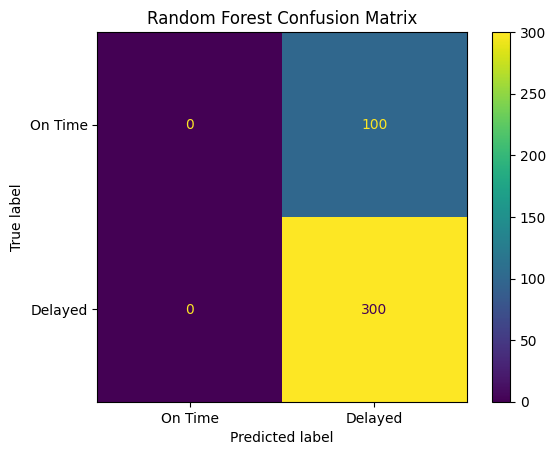

In [22]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["On Time", "Delayed"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [25]:
# Target construction audit

raw_df = pd.read_csv("../data/public_transport_delays.csv")

target_from_delay = (
    raw_df["actual_arrival_delay_min"] > 5
).astype(int)

agreement = (
    raw_df["delayed"] == target_from_delay
).mean()

print(f"Target agreement with actual_arrival_delay_min > 5: {agreement:.2%}")

Target agreement with actual_arrival_delay_min > 5: 100.00%


## Classification Finding

The target variable `delayed` was found to have 100% agreement with the rule:

`delayed = 1` when `actual_arrival_delay_min > 5`, otherwise `0`.

Because `actual_arrival_delay_min` is an outcome variable, it must not be used as a predictor for pre-trip classification.

Using only information available before the trip, the evaluated classifiers showed limited discriminatory ability. The Random Forest predicted all test observations as delayed, producing 75% accuracy but only 0.50 balanced accuracy and approximately 0.48 ROC-AUC.

Therefore, the classification results indicate that the supplied dataset does not contain sufficient pre-trip signal to reliably predict the constructed delay label. This is treated as a dataset limitation rather than addressed through data leakage or artificial performance optimisation.